# Salary Regression Analysis (Kaggle Dataset)

Goal: predict `salary` from demographic and job features using linear regression (gradient descent), decision tree, and random forest.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

### Data Loading and Cleaning
Runs dataset download, column normalization, numeric casting, and target-missing cleanup.

In [4]:
def normalize_columns(columns):
    return [c.strip().lower().replace(' ', '_') for c in columns]

def load_salary_data():
    try:
        import kagglehub
        dataset_path = Path(kagglehub.dataset_download('mohithsairamreddy/salary-data'))
        csv_files = list(dataset_path.rglob('*.csv'))
        if not csv_files:
            raise FileNotFoundError('No CSV file found in downloaded dataset.')
        temp = pd.read_csv(csv_files[0])
        temp.columns = normalize_columns(temp.columns)
        return temp, str(csv_files[0])
    except Exception as exc:
        raise FileNotFoundError(
            'Kaggle salary dataset download failed. '
            'Install kagglehub and ensure internet access. '
            f'Root cause: {exc}'
        )

df, source_path = load_salary_data()

# Ensure key modeling columns are numeric when possible.
for col in ['age', 'years_of_experience', 'salary']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Target cannot contain NaN for supervised learning.
if 'salary' in df.columns:
    before_rows = len(df)
    df = df.dropna(subset=['salary']).copy()
    dropped = before_rows - len(df)
    print(f'Rows dropped due to missing salary: {dropped}')

print(f'Dataset source: {source_path}')

Rows dropped due to missing salary: 5
Dataset source: C:\Users\ibyis\.cache\kagglehub\datasets\mohithsairamreddy\salary-data\versions\4\Salary_Data.csv


### Load and Prepare Dataset
Downloads the salary dataset from Kaggle, normalizes column names, converts key numeric fields, and removes rows with missing target values.

### Quick Data Checks
These cells print the dataset shape, preview rows, summary statistics, and missing values.

In [7]:
print(f'Shape: {df.shape}')

Shape: (6699, 6)


### Data Preview
Shows a quick sample of rows from the dataset.

In [9]:
display(df.head())

,age,gender,education_level,job_title,years_of_experience,salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


### Descriptive Statistics
Displays summary statistics across available columns.

### Preview First Rows
Displays the first few records to quickly inspect data values and columns.

In [12]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,6699.0,NaN,NaN,NaN,33.622033,7.615646,21.0,28.0,32.0,38.0,62.0
gender,6699,3,Male,3672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,6698,7,Bachelor's Degree,2265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,6699,192,Software Engineer,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_of_experience,6699.0,NaN,NaN,NaN,8.095014,6.059853,0.0,3.0,7.0,12.0,34.0
salary,6699.0,NaN,NaN,NaN,115326.964771,52786.183911,350.0,70000.0,115000.0,160000.0,250000.0


### Missing-Value Intro
Prints a heading before the missing-value totals.

### Summary Statistics
Shows descriptive statistics for both numeric and categorical features.

In [15]:
print('\nMissing values per column:')


Missing values per column:


### Missing-Value Counts
Shows the number of missing values in each column.

### Missing-Value Section Header
Prints a label before showing missing-value counts per column.

In [18]:
print(df.isnull().sum())

age                    0
gender                 0
education_level        1
job_title              0
years_of_experience    0
salary                 0
dtype: int64


### Missing Values by Column
Displays the number of missing entries for each column.

## Data Visualization and Interpretation

### Visual 1: Salary Distribution and Experience Relationship

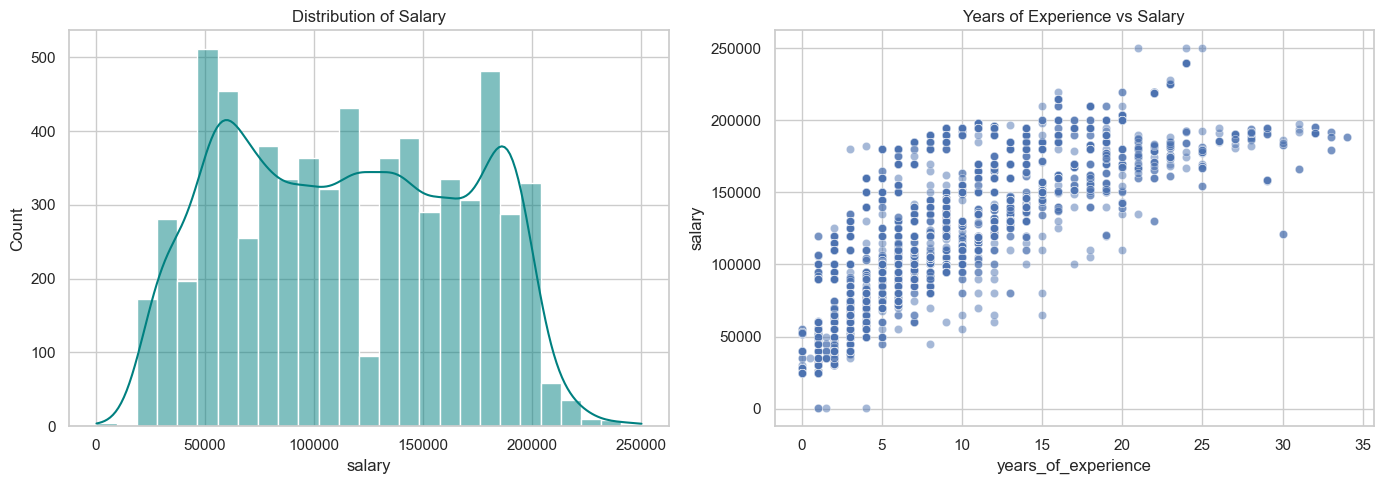

In [22]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
target_col = 'salary'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[target_col], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Salary')
sns.scatterplot(data=df, x='years_of_experience', y=target_col, ax=axes[1], alpha=0.5)
axes[1].set_title('Years of Experience vs Salary')
plt.tight_layout()
plt.show()

### Visual 2: Numeric Correlation Heatmap

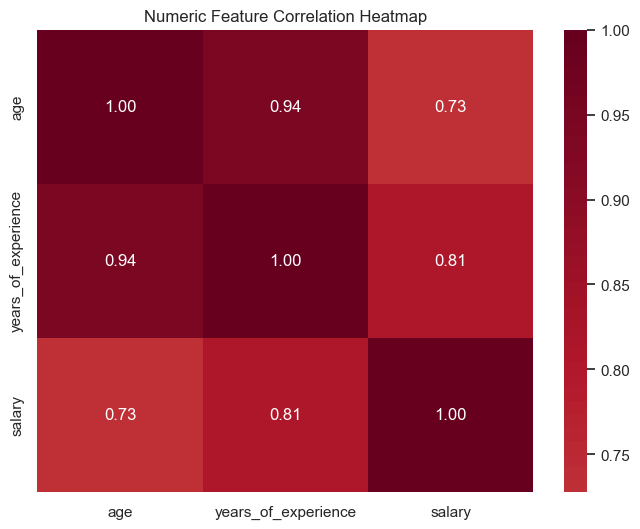

In [24]:
plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Numeric Feature Correlation Heatmap')
plt.show()

### Visual 3: Salary by Education Level and Gender

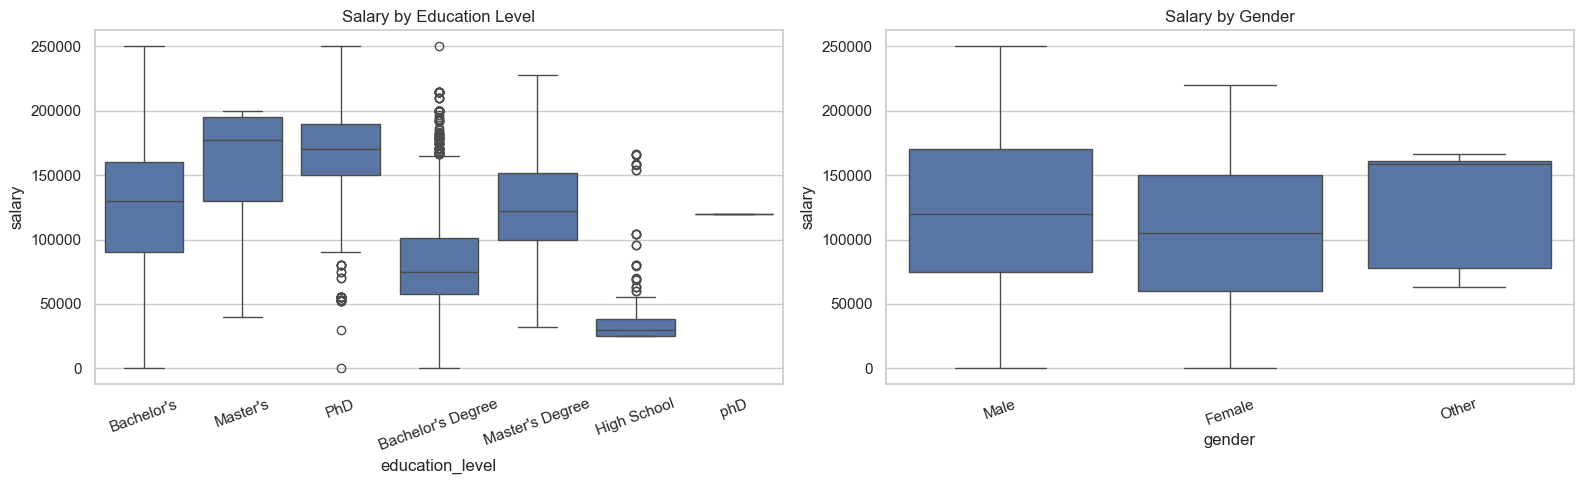

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df, x='education_level', y=target_col, ax=axes[0])
axes[0].set_title('Salary by Education Level')
axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='gender', y=target_col, ax=axes[1])
axes[1].set_title('Salary by Gender')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### Correlation Interpretation
Summarizes how strongly each numeric feature relates to salary.

In [28]:
corr_to_target = corr[target_col].sort_values(ascending=False)
print('Correlation with salary:')
print(corr_to_target)

print('\nInterpretation notes:')
print('- Years of experience usually has the strongest positive relationship with salary.')
print('- Age may correlate with salary but can be partially redundant with experience.')
print('- Categorical features (education_level, job_title, gender) must be converted to numeric via one-hot encoding.')

Correlation with salary:
salary                 1.000000
years_of_experience    0.808969
age                    0.728053
Name: salary, dtype: float64

Interpretation notes:
- Years of experience usually has the strongest positive relationship with salary.
- Age may correlate with salary but can be partially redundant with experience.
- Categorical features (education_level, job_title, gender) must be converted to numeric via one-hot encoding.


## Feature Engineering

- Target is `salary`.
- Drop leakage-prone columns if present (e.g., salary bins/labels).
- Keep numeric features such as `age` and `years_of_experience`.
- Convert categorical columns to numeric using one-hot encoding.
- Standardize numeric columns using `StandardScaler` for gradient-based linear regression.

### Step 1: Validate and Select Features
Checks required columns, removes leakage columns if present, and defines X and y.

In [31]:
required_cols = {'age', 'gender', 'education_level', 'job_title', 'years_of_experience', 'salary'}
missing_required = required_cols - set(df.columns)
if missing_required:
    raise ValueError(f'Missing expected columns: {missing_required}')

drop_cols = [c for c in ['salary_classification', 'salary_range', 'high_low_salary'] if c in df.columns]
feature_cols = [c for c in df.columns if c not in drop_cols + [target_col]]
X = df[feature_cols].copy()
y = df[target_col].copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print('Feature columns used:')
print(feature_cols)
print('\nNumeric features (standardized):', numeric_features)
print('Categorical features (one-hot encoded):', categorical_features)

Feature columns used:
['age', 'gender', 'education_level', 'job_title', 'years_of_experience']

Numeric features (standardized): ['age', 'years_of_experience']
Categorical features (one-hot encoded): ['gender', 'education_level', 'job_title']


### Step 2: Train/Test Split
Splits the dataset into training and testing subsets for fair evaluation.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train set shape: {X_train.shape}, Test set shape: {X_test.shape}')

Train set shape: (5359, 5), Test set shape: (1340, 5)


### Step 3: Build Preprocessing Pipelines
Creates imputers, scaling, one-hot encoding, and combines them in a ColumnTransformer.

In [35]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

### Step 4: Apply Preprocessing
Fits preprocessing on training data, transforms test data, and prints transformed shapes.

In [37]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print('\nTransformed train shape:', X_train_prep.shape)
print('Transformed test shape:', X_test_prep.shape)


Transformed train shape: (5359, 180)
Transformed test shape: (1340, 180)


## Linear Regression (Gradient Descent with scikit-learn)

This section trains an `SGDRegressor` (linear model optimized by gradient descent), tracks train/test loss by epoch, and keeps the best hyperparameters.

### Step 1: Configure Hyperparameters and Validate Inputs
Sets alpha, learning rate, and epochs, then checks for NaN values before training.

In [40]:
alphas = [1e-4, 1e-3, 1e-2]
eta0_values = [0.001, 0.01, 0.05]
epochs = 150

x_train_has_nan = np.isnan(X_train_prep.data).any() if hasattr(X_train_prep, 'data') else np.isnan(np.asarray(X_train_prep)).any()
x_test_has_nan = np.isnan(X_test_prep.data).any() if hasattr(X_test_prep, 'data') else np.isnan(np.asarray(X_test_prep)).any()
y_train_has_nan = y_train.isna().any()
y_test_has_nan = y_test.isna().any()

if x_train_has_nan or x_test_has_nan or y_train_has_nan or y_test_has_nan:
    raise ValueError('NaN detected. Re-run data loading and preprocessing cells before this cell.')

### Step 2: Initialize Best-Model Tracking
Creates variables to store the best model, parameters, and train/test loss curves.

In [ ]:
best_lr_model = None
best_lr_rmse = np.inf
best_lr_r2 = None
best_lr_params = None
best_train_curve = None
best_test_curve = None

### Step 3: Train SGD(Stochastic gradient descent) Models Across Hyperparameters
Runs gradient-descent training for each alpha/eta0 pair and keeps the best-performing setup.

In [44]:
for alpha in alphas:
    for eta0 in eta0_values:
        model = SGDRegressor(
            loss='squared_error',
            penalty='l2',
            alpha=alpha,
            learning_rate='constant',
            eta0=eta0,
            max_iter=1,
            tol=None,
            random_state=RANDOM_STATE
        )

        train_curve = []
        test_curve = []

        for _ in range(epochs):
            model.partial_fit(X_train_prep, y_train)
            train_pred = model.predict(X_train_prep)
            test_pred = model.predict(X_test_prep)
            train_curve.append(mean_squared_error(y_train, train_pred))
            test_curve.append(mean_squared_error(y_test, test_pred))

        final_test_pred = model.predict(X_test_prep)
        rmse = np.sqrt(mean_squared_error(y_test, final_test_pred))
        r2 = r2_score(y_test, final_test_pred)

        if rmse < best_lr_rmse:
            best_lr_rmse = rmse
            best_lr_r2 = r2
            best_lr_model = model
            best_lr_params = {'alpha': alpha, 'eta0': eta0, 'epochs': epochs}
            best_train_curve = train_curve
            best_test_curve = test_curve

### Step 4: Report Best Linear Model Metrics
Prints the selected hyperparameters and performance metrics of the best SGD model.

In [46]:
print('Best linear (SGD) params:', best_lr_params)
print(f'Linear SGD RMSE: {best_lr_rmse:.4f}')
print(f'Linear SGD R2: {best_lr_r2:.4f}')

Best linear (SGD) params: {'alpha': 0.0001, 'eta0': 0.01, 'epochs': 150}
Linear SGD RMSE: 18796.5598
Linear SGD R2: 0.8757


### Loss-Curve Visualization
Plots train and test MSE across epochs for the best SGD model.

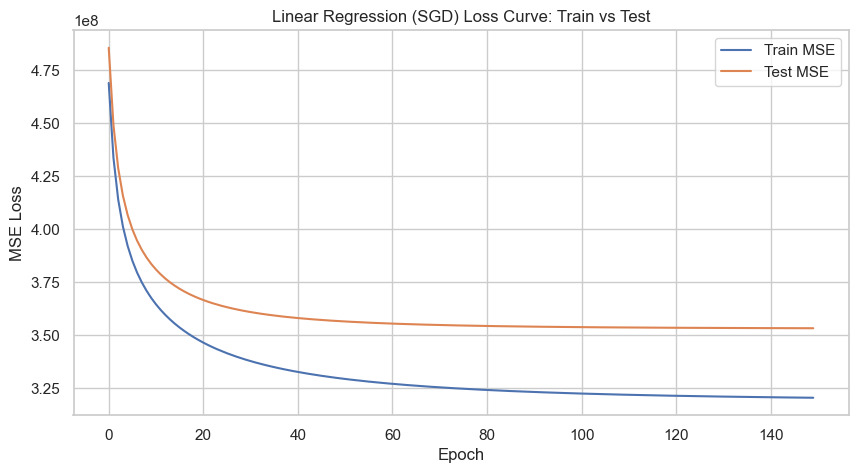

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(best_train_curve, label='Train MSE')
plt.plot(best_test_curve, label='Test MSE')
plt.title('Linear Regression (SGD) Loss Curve: Train vs Test')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

### Standardization Effect Demo
Compares a simple linear fit before and after feature scaling.

C:\Users\ibyis\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


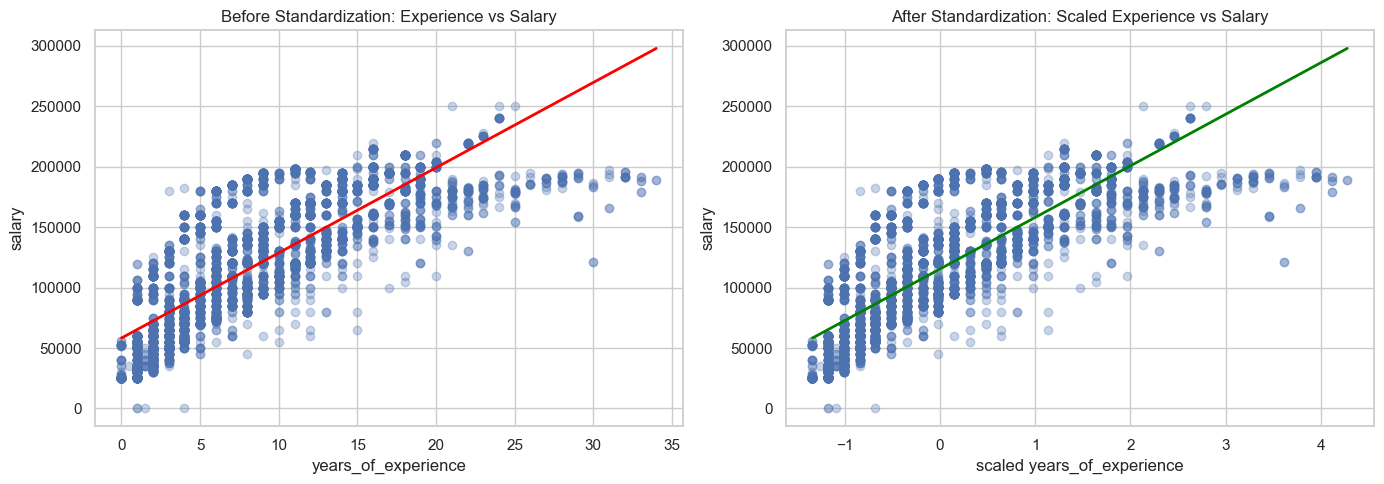

In [50]:
x_raw = df[['years_of_experience']].copy()
y_raw = df[target_col].copy()

simple_lr_before = LinearRegression()
simple_lr_before.fit(x_raw, y_raw)
x_line = np.linspace(x_raw.min().item(), x_raw.max().item(), 200).reshape(-1, 1)
y_line_before = simple_lr_before.predict(x_line)

x_scaler = StandardScaler()
x_scaled = x_scaler.fit_transform(x_raw)
simple_lr_after = LinearRegression()
simple_lr_after.fit(x_scaled, y_raw)
x_line_scaled = np.linspace(x_scaled.min(), x_scaled.max(), 200).reshape(-1, 1)
y_line_after = simple_lr_after.predict(x_line_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(x_raw, y_raw, alpha=0.3)
axes[0].plot(x_line, y_line_before, color='red', linewidth=2)
axes[0].set_title('Before Standardization: Experience vs Salary')
axes[0].set_xlabel('years_of_experience')
axes[0].set_ylabel('salary')

axes[1].scatter(x_scaled, y_raw, alpha=0.3)
axes[1].plot(x_line_scaled, y_line_after, color='green', linewidth=2)
axes[1].set_title('After Standardization: Scaled Experience vs Salary')
axes[1].set_xlabel('scaled years_of_experience')
axes[1].set_ylabel('salary')

plt.tight_layout()
plt.show()

## Decision Tree Regressor

In [52]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=8, min_samples_split=10, random_state=RANDOM_STATE))
])

dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)
print(f'Decision Tree RMSE: {dt_rmse:.4f}')
print(f'Decision Tree R2: {dt_r2:.4f}')

Decision Tree RMSE: 13788.1430
Decision Tree R2: 0.9331


## Random Forest Regressor

In [54]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f'Random Forest RMSE: {rf_rmse:.4f}')
print(f'Random Forest R2: {rf_r2:.4f}')

Random Forest RMSE: 6607.7025
Random Forest R2: 0.9846


### Compare Model Performance
Builds a model-comparison table and identifies the best model by RMSE.

In [56]:
results = pd.DataFrame([
    {'Model': 'LinearRegression_SGD', 'RMSE': best_lr_rmse, 'R2': best_lr_r2},
    {'Model': 'DecisionTree', 'RMSE': dt_rmse, 'R2': dt_r2},
    {'Model': 'RandomForest', 'RMSE': rf_rmse, 'R2': rf_r2}
]).sort_values('RMSE')
display(results)

best_model_name = results.iloc[0]['Model']

if best_model_name == 'LinearRegression_SGD':
    artifact = {
        'model_name': best_model_name,
        'model_type': 'separate',
        'preprocessor': preprocessor,
        'model': best_lr_model,
        'feature_columns': feature_cols,
        'target_column': target_col
    }
elif best_model_name == 'DecisionTree':
    artifact = {
        'model_name': best_model_name,
        'model_type': 'pipeline',
        'pipeline': dt_pipeline,
        'feature_columns': feature_cols,
        'target_column': target_col
    }
else:
    artifact = {
        'model_name': best_model_name,
        'model_type': 'pipeline',
        'pipeline': rf_pipeline,
        'feature_columns': feature_cols,
        'target_column': target_col
    }

with open('best_model_salary.pkl', 'wb') as file:
    pickle.dump(artifact, file)
print(f'Best model saved as best_model_salary.pkl -> {best_model_name}')

,Model,RMSE,R2
2,RandomForest,6607.702539,0.984642
1,DecisionTree,13788.142975,0.933129
0,LinearRegression_SGD,18796.559848,0.875724


Best model saved as best_model_salary.pkl -> RandomForest


### Accuracy Proxy Table
Shows an accuracy-style table using R2 converted to percentage.

In [58]:
accuracy_table = results[['Model', 'RMSE', 'R2']].copy()
accuracy_table['Accuracy (%)'] = (accuracy_table['R2'] * 100).round(2)
accuracy_table = accuracy_table[['Model', 'Accuracy (%)', 'RMSE', 'R2']].sort_values('Accuracy (%)', ascending=False)

print('Model accuracy table (using R2 as accuracy proxy):')
display(accuracy_table)

Model accuracy table (using R2 as accuracy proxy):


,Model,Accuracy (%),RMSE,R2
2,RandomForest,98.46,6607.702539,0.984642
1,DecisionTree,93.31,13788.142975,0.933129
0,LinearRegression_SGD,87.57,18796.559848,0.875724


### Load Best Model and Predict Sample
Loads the saved best model artifact and predicts salary for a sample input row.

In [ ]:

with open('best_model_salary.pkl', 'rb') as file:
    loaded = pickle.load(file)

sample_input = pd.DataFrame([
    {
        'age': 32,
        'gender': 'Male',
        'education_level': "Master's",
        'job_title': 'Data Analyst',
        'years_of_experience': 7
    },
    {
        'age': 25,
        'gender': 'Male',
        'education_level': "Bachelor's",
        'job_title': 'Software Engineer',
        'years_of_experience': 2
    }
])

if loaded['model_type'] == 'pipeline':
    preds = loaded['pipeline'].predict(sample_input)
else:
    transformed = loaded['preprocessor'].transform(sample_input)
    preds = loaded['model'].predict(transformed)

results_df = sample_input.copy()
results_df.insert(0, 'Input #', [f'Input {i+1}' for i in range(len(sample_input))])
results_df['Predicted Salary ($)'] = preds.round(2)

print('Salary predictions per sample input:')
display(results_df)


Predicted salary: 122634.65
